TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Downloaded to: /kaggle/input/brain-tumor-mri-dataset
Using DATA_DIR: /kaggle/input/brain-tumor-mri-dataset
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
train:  4760 images  {'glioma': 1190, 'meningioma': 1190, 'notumor': 1190, 'pituitary': 1190}
  val:   840 images  {'glioma': 210, 'meningioma': 210, 'notumor': 210, 'pituitary': 210}
 test:  1600 images  {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ACGHV"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_rescale         │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_patches         │ (None, None, 768) │          0 │ vit_rescale[0][0] │
│ (Patches)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_patch_encoder   │ (None, 196, 256)  │    247,040 │ vit_patches[0][0] │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 256)  │        512 │ vit_patch_encode… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 256)  │          0 │ multi_head_atten… │
│                     │                   │            │ vit_patch_encode… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 196, 512)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 256)  │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 196, 256)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 256)  │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 256)  │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,856,559 (29.97 MB)

 Trainable params: 5,290,348 (20.18 MB)

 Non-trainable params: 2,566,211 (9.79 MB)

Epoch 1/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 221s 899ms/step - cnn_aux_loss: 0.6044 - final_output_accuracy: 0.7521 - final_output_loss: 0.6352 - loss: 1.1495 - vit_aux_loss: 1.1060 - val_cnn_aux_loss: 0.5187 - val_final_output_accuracy: 0.8536 - val_final_output_loss: 0.3941 - val_loss: 0.8506 - val_vit_aux_loss: 1.0370 - learning_rate: 1.0000e-04
Epoch 2/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 67s 445ms/step - cnn_aux_loss: 0.3378 - final_output_accuracy: 0.8676 - final_output_loss: 0.3501 - loss: 0.7338 - vit_aux_loss: 0.9417 - val_cnn_aux_loss: 0.5476 - val_final_output_accuracy: 0.8298 - val_final_output_loss: 0.4689 - val_loss: 0.9123 - val_vit_aux_loss: 0.9648 - learning_rate: 1.0000e-04
Epoch 3/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 67s 449ms/step - cnn_aux_loss: 0.2742 - final_output_accuracy: 0.8945 - final_output_loss: 0.2836 - loss: 0.6257 - vit_aux_loss: 0.8666 - val_cnn_aux_loss: 0.2974 - val_final_output_accuracy: 0.9012 - val_final_output_loss: 0.3109 - val_loss: 0.6112 - val_vit_aux_loss:

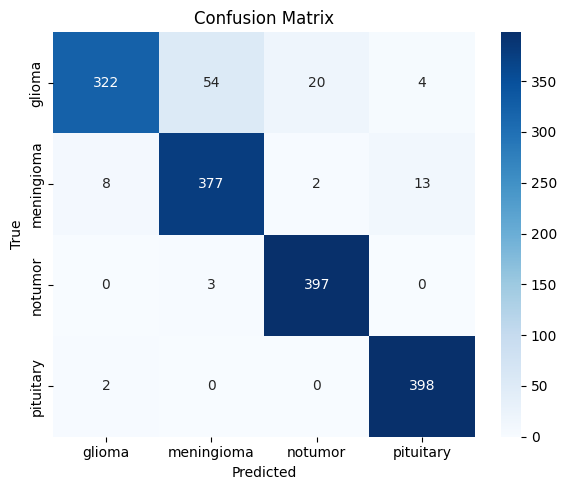

Specificity per class: {'glioma': np.float64(0.9916666666584029), 'meningioma': np.float64(0.9524999999920626), 'notumor': np.float64(0.9816666666584862), 'pituitary': np.float64(0.9858333333251181)}
Where each true class went (rows = true, cols = predicted):
              glioma: glioma=322, meningioma=54, notumor=20, pituitary=4
          meningioma: glioma=8, meningioma=377, notumor=2, pituitary=13
             notumor: glioma=0, meningioma=3, notumor=397, pituitary=0
           pituitary: glioma=2, meningioma=0, notumor=0, pituitary=398


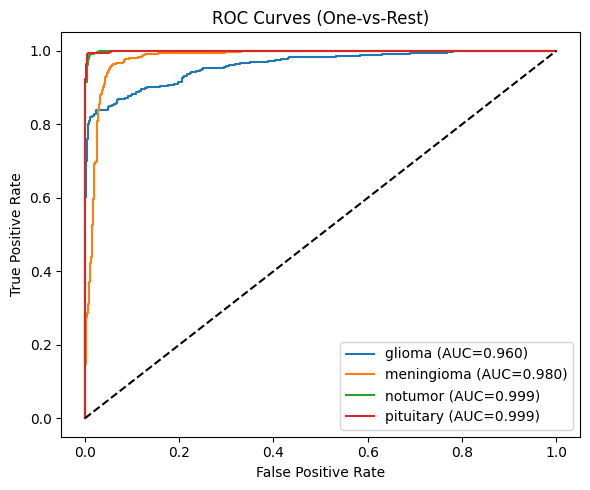

Macro AUC-ROC: 0.9847
Overall test accuracy: 93.38%


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: mri_input
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: mri_input
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


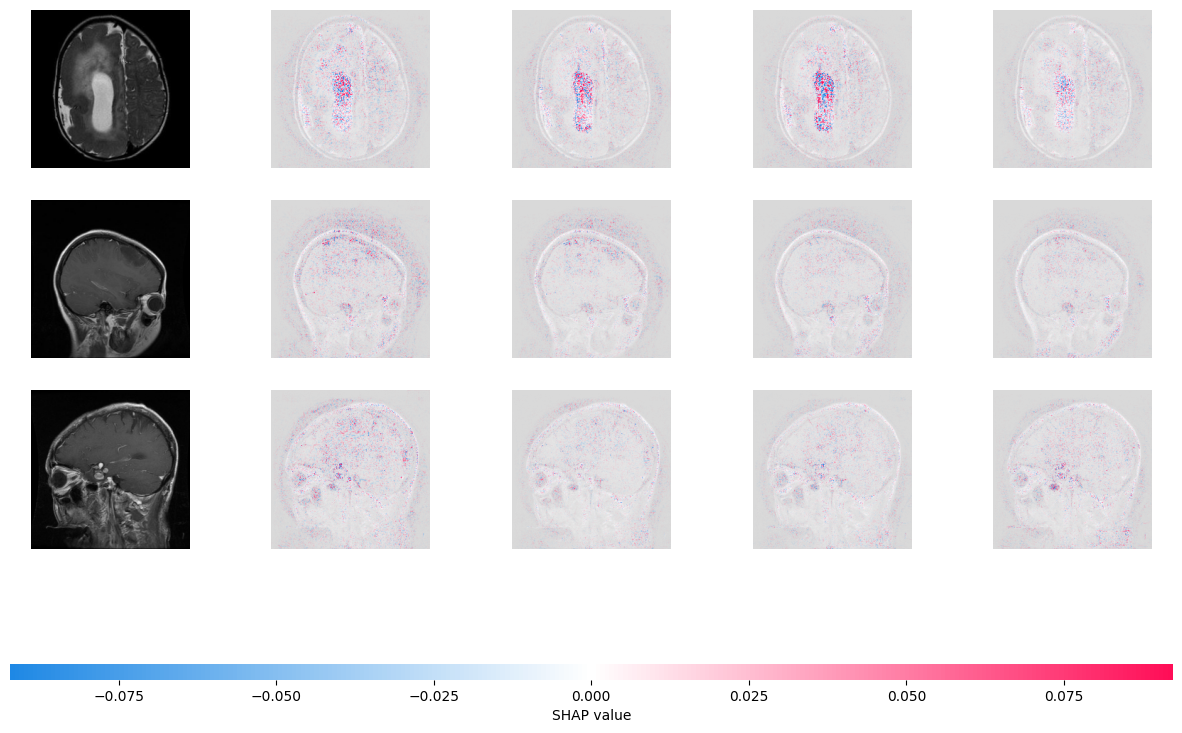

In [1]:
"""
Adaptive Confidence-Guided Explainable Hybrid CNN-ViT Framework
for Brain Tumor Classification Using MRI Images.

COLAB-READY VERSION: paste this whole file into a Colab cell (or a few
cells split at the "# ---" markers) and run top to bottom. It:
  1. Installs deps
  2. Downloads the Kaggle dataset (sartajbhuvaji/brain-tumor-classification-mri)
  3. Builds + trains + evaluates the hybrid CNN-ViT model from the paper
  4. Produces Grad-CAM and SHAP explanations on a few test images

Architecture maps to the paper as:
  CNN branch                              -> Section 4.4, Eq. (1)
  ViT branch                              -> Section 4.5, Eq. (2)
  Adaptive confidence-guided fusion       -> Section 4.6, Eq. (3)-(6)
  Classification head                     -> Section 4.7, Eq. (7)-(8)
  Explainability (Grad-CAM + SHAP)        -> Section 4.8
"""

# --------------------------------------------------------------------------
# 0. Install dependencies (Colab already has tensorflow; the rest are extra)
# --------------------------------------------------------------------------
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                 "kagglehub", "shap", "opencv-python-headless", "seaborn"])

import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# --------------------------------------------------------------------------
# 1. Download dataset and locate Training/Testing folders
# --------------------------------------------------------------------------
import kagglehub

# WHY GLIOMA RECALL WAS ~19%:
# The SARTAJ dataset (sartajbhuvaji/brain-tumor-classification-mri) has a
# known labelling problem in its glioma class, and its official Testing/
# folder does not come from the same distribution as Training/. The model
# learns "Training glioma", then sees different-looking "Testing glioma"
# scans and calls them meningioma / no tumor -> 100% precision, 19% recall.
#
# Options:
#   "masoud" (RECOMMENDED): masoudnickparvar/brain-tumor-mri-dataset, 7,023
#            images; its author replaced SARTAJ's glioma images with the
#            correctly labelled figshare ones. Official Train/Test split used.
#   "sartaj": the original dataset, but Training+Testing are pooled and
#            re-split with a stratified split so test matches train.
#            (Glioma labels are still noisy, so expect a lower ceiling.)
DATASET = "masoud"

DATASET_SLUGS = {
    "masoud": "masoudnickparvar/brain-tumor-mri-dataset",
    "sartaj": "sartajbhuvaji/brain-tumor-classification-mri",
}
download_root = kagglehub.dataset_download(DATASET_SLUGS[DATASET])
print("Downloaded to:", download_root)


def find_data_dir(root):
    """Locate the folder that directly contains Training/ and Testing/."""
    for dirpath, dirnames, _ in os.walk(root):
        if "Training" in dirnames and "Testing" in dirnames:
            return dirpath
    raise FileNotFoundError(
        f"Could not find Training/ and Testing/ folders under {root}. "
        f"Contents: {os.listdir(root)}"
    )


DATA_DIR = find_data_dir(download_root)
print("Using DATA_DIR:", DATA_DIR)

if not tf.config.list_physical_devices("GPU"):
    print("WARNING: no GPU found. In Colab: Runtime > Change runtime type > T4 GPU. "
          "On CPU each epoch takes ~15 min.")

# --------------------------------------------------------------------------
# 2. Config
# --------------------------------------------------------------------------
IMG_SIZE = 224
# Read class folders from disk (SARTAJ: glioma_tumor, ...; Masoud: glioma, ...)
CLASS_NAMES = sorted(
    d for d in os.listdir(os.path.join(DATA_DIR, "Training"))
    if os.path.isdir(os.path.join(DATA_DIR, "Training", d))
)
NUM_CLASSES = len(CLASS_NAMES)
assert NUM_CLASSES == 4, f"Expected 4 classes, found {CLASS_NAMES}"
print("Classes:", CLASS_NAMES)

PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2      # 196
PROJ_DIM = 256
TRANSFORMER_LAYERS = 6
NUM_HEADS = 8
MLP_DIM = 512
DROPOUT = 0.1

EPOCHS = 40
BATCH_SIZE = 32
LR = 1e-4

AUTOTUNE = tf.data.AUTOTUNE

# --------------------------------------------------------------------------
# 3. Data pipeline (Section 4.3: resize, normalize, augment)
# --------------------------------------------------------------------------
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")


def list_files(split_dir):
    paths, labels = [], []
    for idx, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(split_dir, cls)
        for f in sorted(os.listdir(cls_dir)):
            if f.lower().endswith(IMG_EXTS):
                paths.append(os.path.join(cls_dir, f))
                labels.append(idx)
    return np.array(paths), np.array(labels)


def make_splits(data_dir, val_split=0.15, test_split=0.15, seed=42):
    """Stratified splits so every class has the same share in train/val/test."""
    from sklearn.model_selection import train_test_split
    tr_p, tr_y = list_files(os.path.join(data_dir, "Training"))
    te_p, te_y = list_files(os.path.join(data_dir, "Testing"))

    if DATASET == "sartaj":
        # Official SARTAJ test split is mismatched -> pool and re-split.
        all_p, all_y = np.concatenate([tr_p, te_p]), np.concatenate([tr_y, te_y])
        tr_p, te_p, tr_y, te_y = train_test_split(
            all_p, all_y, test_size=test_split, stratify=all_y, random_state=seed)

    tr_p, va_p, tr_y, va_y = train_test_split(
        tr_p, tr_y, test_size=val_split, stratify=tr_y, random_state=seed)

    for name, y in [("train", tr_y), ("val", va_y), ("test", te_y)]:
        counts = {CLASS_NAMES[i]: int((y == i).sum()) for i in range(NUM_CLASSES)}
        print(f"{name:>5}: {len(y):5d} images  {counts}")
    return (tr_p, tr_y), (va_p, va_y), (te_p, te_y)


def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))          # float32, 0-255
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return img, tf.one_hot(label, NUM_CLASSES)


def build_datasets(data_dir, batch_size=BATCH_SIZE, seed=42):
    (tr_p, tr_y), (va_p, va_y), (te_p, te_y) = make_splits(data_dir, seed=seed)

    augment = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.06),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomContrast(0.08),
    ], name="augmentation")

    def to_targets(x, y):
        # each branch does its own internal preprocessing (see model below)
        return x, {"final_output": y, "cnn_aux": y, "vit_aux": y}

    def base_ds(paths, labels):
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        return ds.map(load_image, num_parallel_calls=AUTOTUNE)

    # FIX: cache the *decoded* images, THEN shuffle + augment. The old code
    # cached after augmentation, so every epoch replayed epoch-1's augmented
    # images and augmentation effectively switched off.
    train_ds = (base_ds(tr_p, tr_y).cache()
                .shuffle(len(tr_p), seed=seed, reshuffle_each_iteration=True)
                .batch(batch_size)
                .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
                .map(to_targets, num_parallel_calls=AUTOTUNE)
                .prefetch(AUTOTUNE))
    val_ds = (base_ds(va_p, va_y).batch(batch_size).map(to_targets)
              .cache().prefetch(AUTOTUNE))
    test_ds = base_ds(te_p, te_y).batch(batch_size)            # unshuffled
    test_ds_labeled = test_ds.map(to_targets).prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds_labeled, test_ds


# --------------------------------------------------------------------------
# 4. ViT branch -> Eq. (2): F_vit = ViT(I)
# --------------------------------------------------------------------------
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        return tf.reshape(patches, [batch_size, -1, patch_dims])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"patch_size": self.patch_size})
        return cfg


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patch) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_patches": self.num_patches, "projection_dim": self.projection.units})
        return cfg


def transformer_encoder_block(x, projection_dim, num_heads, mlp_dim, dropout=DROPOUT):
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attn = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim // num_heads, dropout=dropout
    )(x1, x1)
    x2 = layers.Add()([attn, x])
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    mlp = layers.Dense(mlp_dim, activation=tf.nn.gelu)(x3)
    mlp = layers.Dropout(dropout)(mlp)
    mlp = layers.Dense(projection_dim)(mlp)
    mlp = layers.Dropout(dropout)(mlp)
    return layers.Add()([mlp, x2])


def build_vit_branch(raw_input):
    x = layers.Rescaling(1.0 / 255.0, name="vit_rescale")(raw_input)
    patches = Patches(PATCH_SIZE, name="vit_patches")(x)
    encoded = PatchEncoder(NUM_PATCHES, PROJ_DIM, name="vit_patch_encoder")(patches)
    h = encoded
    for _ in range(TRANSFORMER_LAYERS):
        h = transformer_encoder_block(h, PROJ_DIM, NUM_HEADS, MLP_DIM)
    h = layers.LayerNormalization(epsilon=1e-6)(h)
    f_vit = layers.GlobalAveragePooling1D(name="vit_gap")(h)   # F_vit
    return f_vit


# --------------------------------------------------------------------------
# 5. CNN branch -> Eq. (1): F_cnn = CNN(I)
# --------------------------------------------------------------------------
def build_cnn_branch(raw_input, fine_tune_last_n=30):
    x = layers.Lambda(
        tf.keras.applications.efficientnet.preprocess_input, name="cnn_preprocess"
    )(raw_input)
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base._name = "cnn_backbone"
    for layer in base.layers[:-fine_tune_last_n]:
        layer.trainable = False
    # FIX: keep BatchNorm frozen while fine-tuning (standard Keras advice);
    # updating BN stats with small MRI batches wrecks the ImageNet features.
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    f_cnn_raw = base(x, training=False)
    f_cnn = layers.Dense(PROJ_DIM, activation="relu", name="cnn_projection")(f_cnn_raw)
    return f_cnn, base


# --------------------------------------------------------------------------
# 6. Adaptive Confidence-Guided Fusion -> Eq. (3)-(6)
# --------------------------------------------------------------------------
class ConfidenceGuidedFusion(layers.Layer):
    """
    C_i    = softmax confidence of branch i (max class probability)  (Eq. 3)
    alpha  = C_cnn / (C_cnn + C_vit)                                  (Eq. 4)
    beta   = C_vit / (C_cnn + C_vit)                                  (Eq. 4)
    F_fuse = alpha * F_cnn + beta * F_vit                             (Eq. 5)
    alpha + beta = 1                                                  (Eq. 6)
    """
    def call(self, inputs):
        f_cnn, f_vit, logits_cnn, logits_vit = inputs
        p_cnn = tf.nn.softmax(logits_cnn, axis=-1)
        p_vit = tf.nn.softmax(logits_vit, axis=-1)
        c_cnn = tf.reduce_max(p_cnn, axis=-1, keepdims=True)   # Eq. 3
        c_vit = tf.reduce_max(p_vit, axis=-1, keepdims=True)   # Eq. 3
        denom = c_cnn + c_vit + 1e-8
        alpha = c_cnn / denom                                    # Eq. 4
        beta = c_vit / denom                                     # Eq. 4
        fused = alpha * f_cnn + beta * f_vit                     # Eq. 5
        return fused, alpha, beta


# --------------------------------------------------------------------------
# 7. Full model assembly
# --------------------------------------------------------------------------
def build_acghv_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")

    f_cnn, cnn_backbone = build_cnn_branch(inputs)
    f_vit = build_vit_branch(inputs)

    logits_cnn = layers.Dense(NUM_CLASSES, name="cnn_logits")(f_cnn)
    logits_vit = layers.Dense(NUM_CLASSES, name="vit_logits")(f_vit)

    fused, alpha, beta = ConfidenceGuidedFusion(name="confidence_fusion")(
        [f_cnn, f_vit, logits_cnn, logits_vit]
    )

    x = layers.Dense(256, activation="relu")(fused)
    x = layers.Dropout(0.3)(x)
    final_logits = layers.Dense(NUM_CLASSES, name="final_logits")(x)

    final_output = layers.Activation("softmax", name="final_output")(final_logits)   # Eq. 7
    cnn_aux = layers.Activation("softmax", name="cnn_aux")(logits_cnn)
    vit_aux = layers.Activation("softmax", name="vit_aux")(logits_vit)

    model = Model(inputs=inputs, outputs=[final_output, cnn_aux, vit_aux], name="ACGHV")
    fusion_inspector = Model(inputs=inputs, outputs=[final_output, alpha, beta], name="ACGHV_inspect")

    return model, fusion_inspector, cnn_backbone


def compile_model(model, lr=LR):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss={
            "final_output": "categorical_crossentropy",   # Eq. 8, primary loss
            "cnn_aux": "categorical_crossentropy",
            "vit_aux": "categorical_crossentropy",
        },
        loss_weights={"final_output": 1.0, "cnn_aux": 0.3, "vit_aux": 0.3},
        metrics={"final_output": ["accuracy"]},
    )
    return model


# --------------------------------------------------------------------------
# 8. Training
# --------------------------------------------------------------------------
def train(model, train_ds, val_ds, epochs=EPOCHS, ckpt_path="best_acghv.keras"):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_final_output_accuracy", patience=8,
            restore_best_weights=True, mode="max"
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_final_output_loss", factor=0.5, patience=4, min_lr=1e-7, mode="min"
        ),
        tf.keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_final_output_accuracy",
            save_best_only=True, mode="max"
        ),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks)
    return history


# --------------------------------------------------------------------------
# 9. Evaluation (Section 5.4 / 6.1-6.3)
# --------------------------------------------------------------------------
def evaluate(model, test_ds_labeled):
    y_true, y_pred_probs = [], []
    for batch_x, batch_y in test_ds_labeled:
        preds = model.predict(batch_x, verbose=0)[0]   # final_output branch
        y_pred_probs.append(preds)
        y_true.append(batch_y["final_output"].numpy())
    y_true = np.concatenate(y_true)
    y_pred_probs = np.concatenate(y_pred_probs)
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)

    print(classification_report(y_true_labels, y_pred_labels, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
    plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()

    specificity = {}
    for i, cls in enumerate(CLASS_NAMES):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        specificity[cls] = tn / (tn + fp + 1e-8)
    print("Specificity per class:", specificity)
    print("Where each true class went (rows = true, cols = predicted):")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"  {cls:>18}: " + ", ".join(f"{CLASS_NAMES[j]}={cm[i, j]}" for j in range(NUM_CLASSES)))

    y_true_bin = label_binarize(y_true_labels, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6, 5))
    aucs = []
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (One-vs-Rest)"); plt.legend()
    plt.tight_layout(); plt.savefig("roc_curves.png", dpi=150)
    plt.show()
    print(f"Macro AUC-ROC: {np.mean(aucs):.4f}")

    overall_acc = (y_true_labels == y_pred_labels).mean()
    print(f"Overall test accuracy: {overall_acc*100:.2f}%")
    return overall_acc


# --------------------------------------------------------------------------
# 10. Explainability -> Section 4.8: Grad-CAM (CNN branch) + SHAP
# --------------------------------------------------------------------------
def grad_cam(model, cnn_backbone, image, class_index=None, last_conv_layer_name="top_activation"):
    """
    Grad-CAM on the EfficientNet branch. The backbone is a NESTED model, so
    its inner tensors are not part of the outer graph (that's what caused
    the KeyError). We re-run the forward pass manually instead, reusing the
    trained layers, and take gradients w.r.t. the last conv feature map.
    """
    img = tf.expand_dims(tf.cast(image, tf.float32), axis=0)

    conv_extractor = Model(cnn_backbone.input,
                           cnn_backbone.get_layer(last_conv_layer_name).output)
    vit_model = Model(model.input, model.get_layer("vit_gap").output)

    tail_dense = [l for l in model.layers
                  if isinstance(l, layers.Dense) and l.units == 256
                  and l.activation.__name__ == "relu" and l.name != "cnn_projection"][0]
    tail_dropout = [l for l in model.layers
                    if isinstance(l, layers.Dropout) and abs(l.rate - 0.3) < 1e-6][0]

    pre = model.get_layer("cnn_preprocess")(img)
    f_vit = vit_model(img, training=False)
    logits_vit = model.get_layer("vit_logits")(f_vit)

    with tf.GradientTape() as tape:
        conv_maps = conv_extractor(pre, training=False)
        tape.watch(conv_maps)
        pooled = tf.reduce_mean(conv_maps, axis=(1, 2))
        f_cnn = model.get_layer("cnn_projection")(pooled)
        logits_cnn = model.get_layer("cnn_logits")(f_cnn)
        fused, _, _ = model.get_layer("confidence_fusion")(
            [f_cnn, f_vit, logits_cnn, logits_vit])
        h = tail_dropout(tail_dense(fused), training=False)
        probs = tf.nn.softmax(model.get_layer("final_logits")(h), axis=-1)
        if class_index is None:
            class_index = int(tf.argmax(probs[0]))
        score = probs[:, class_index]

    grads = tape.gradient(score, conv_maps)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(conv_maps[0] @ weights[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def plot_grad_cam(image, heatmap, out_path="gradcam_overlay.png", alpha=0.4):
    import cv2
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    img_uint8 = np.uint8(np.clip(image, 0, 255))
    overlay = cv2.addWeighted(cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR), 1 - alpha, heatmap_color, alpha, 0)
    cv2.imwrite(out_path, overlay)
    return overlay


def shap_explain(model, background_images, sample_images, out_path="shap_summary.png"):
    import shap
    # explain LOGITS (pre-softmax) so gradients don't vanish on confident predictions
    shap_model = Model(model.input, model.get_layer("final_logits").output)
    explainer = shap.GradientExplainer(shap_model, background_images)
    shap_values = explainer.shap_values(sample_images)
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == sample_images.ndim + 1:
        shap_values = [shap_values[..., i] for i in range(shap_values.shape[-1])]
    shap.image_plot(shap_values, sample_images / 255.0, show=False)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    return shap_values



# --------------------------------------------------------------------------
# 11. Run everything
# --------------------------------------------------------------------------
train_ds, val_ds, test_ds_labeled, test_ds_raw = build_datasets(DATA_DIR)

model, fusion_inspector, cnn_backbone = build_acghv_model()
model = compile_model(model)
model.summary()

history = train(model, train_ds, val_ds, epochs=EPOCHS)

test_accuracy = evaluate(model, test_ds_labeled)

# Grad-CAM + SHAP on a handful of test images
sample_batch_x, _ = next(iter(test_ds_labeled))
grad_cam_map = grad_cam(model, cnn_backbone, sample_batch_x[0])
plot_grad_cam(sample_batch_x[0].numpy(), grad_cam_map)

try:
    background = sample_batch_x[:8].numpy()
    samples = sample_batch_x[8:11].numpy()
    shap_explain(model, background, samples)
except Exception as e:
    print("SHAP explanation skipped (optional, can be slow):", e)

Chosen test indices: [377, 650, 1073, 1558, 321, 520]


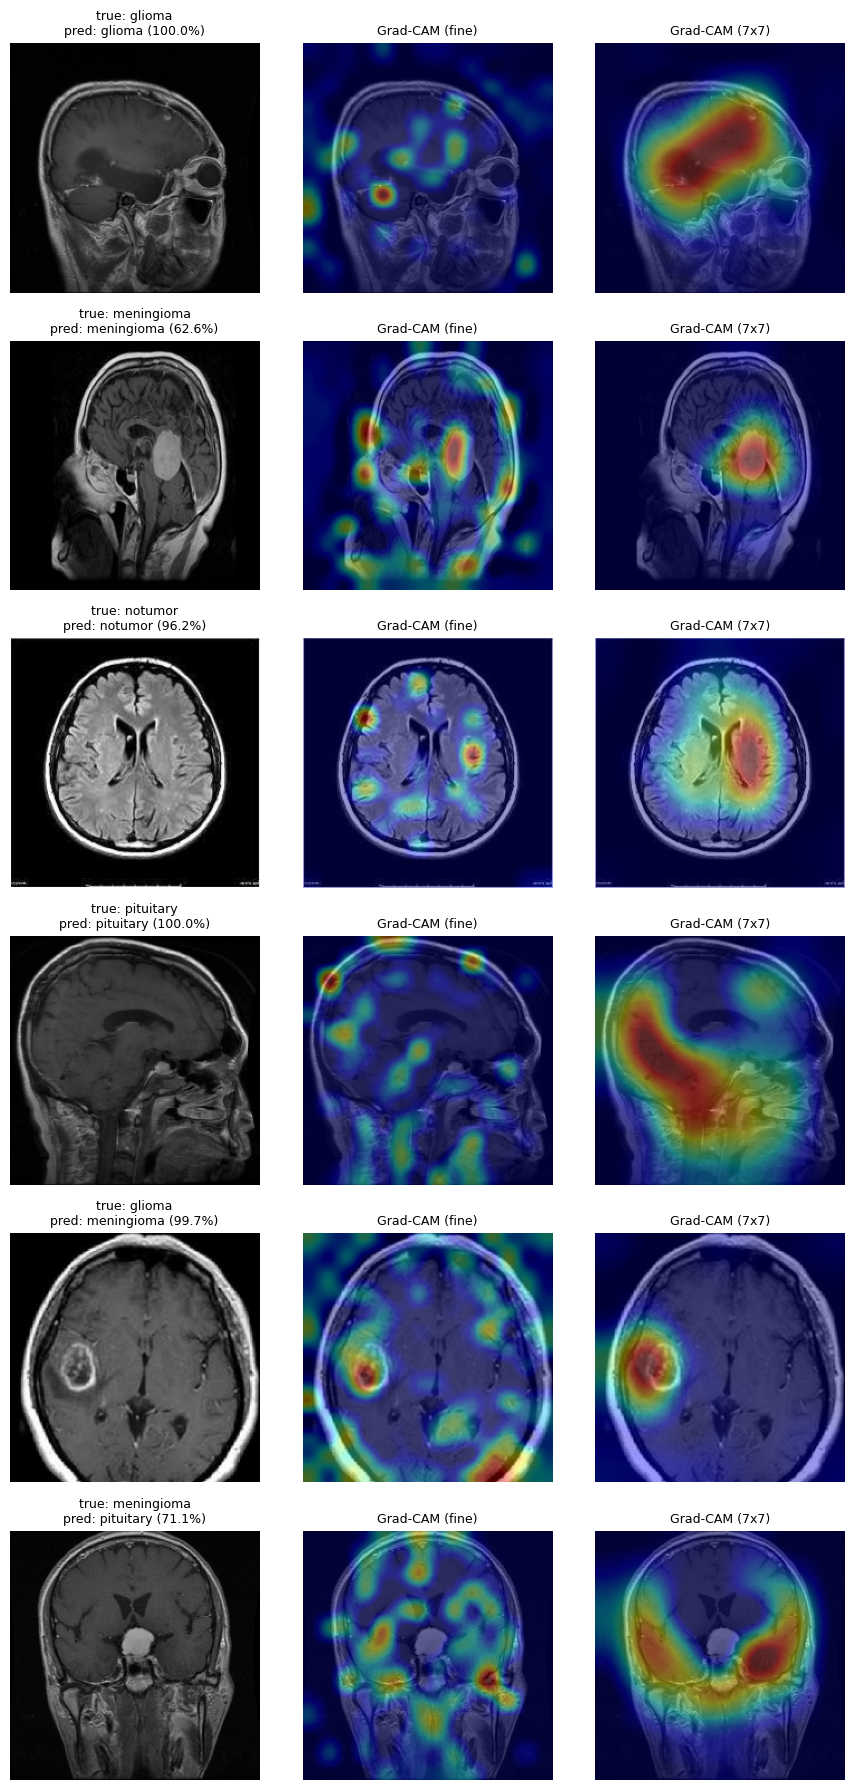

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: mri_input
Received: inputs=['Tensor(shape=(6, 224, 224, 3))']
  warnings.warn(msg)


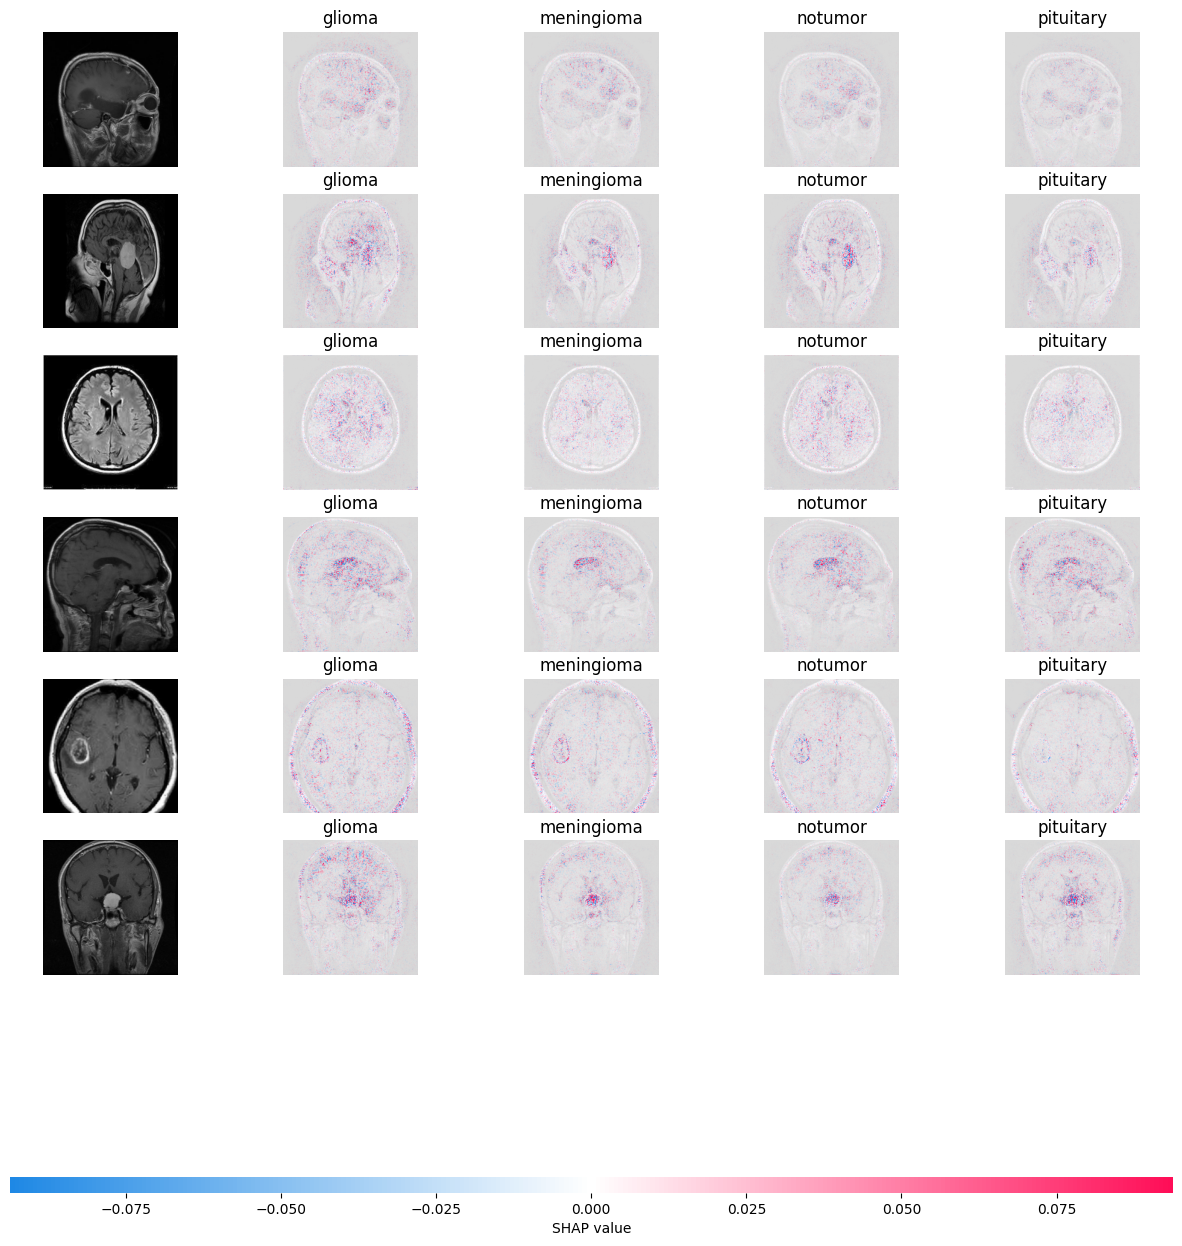

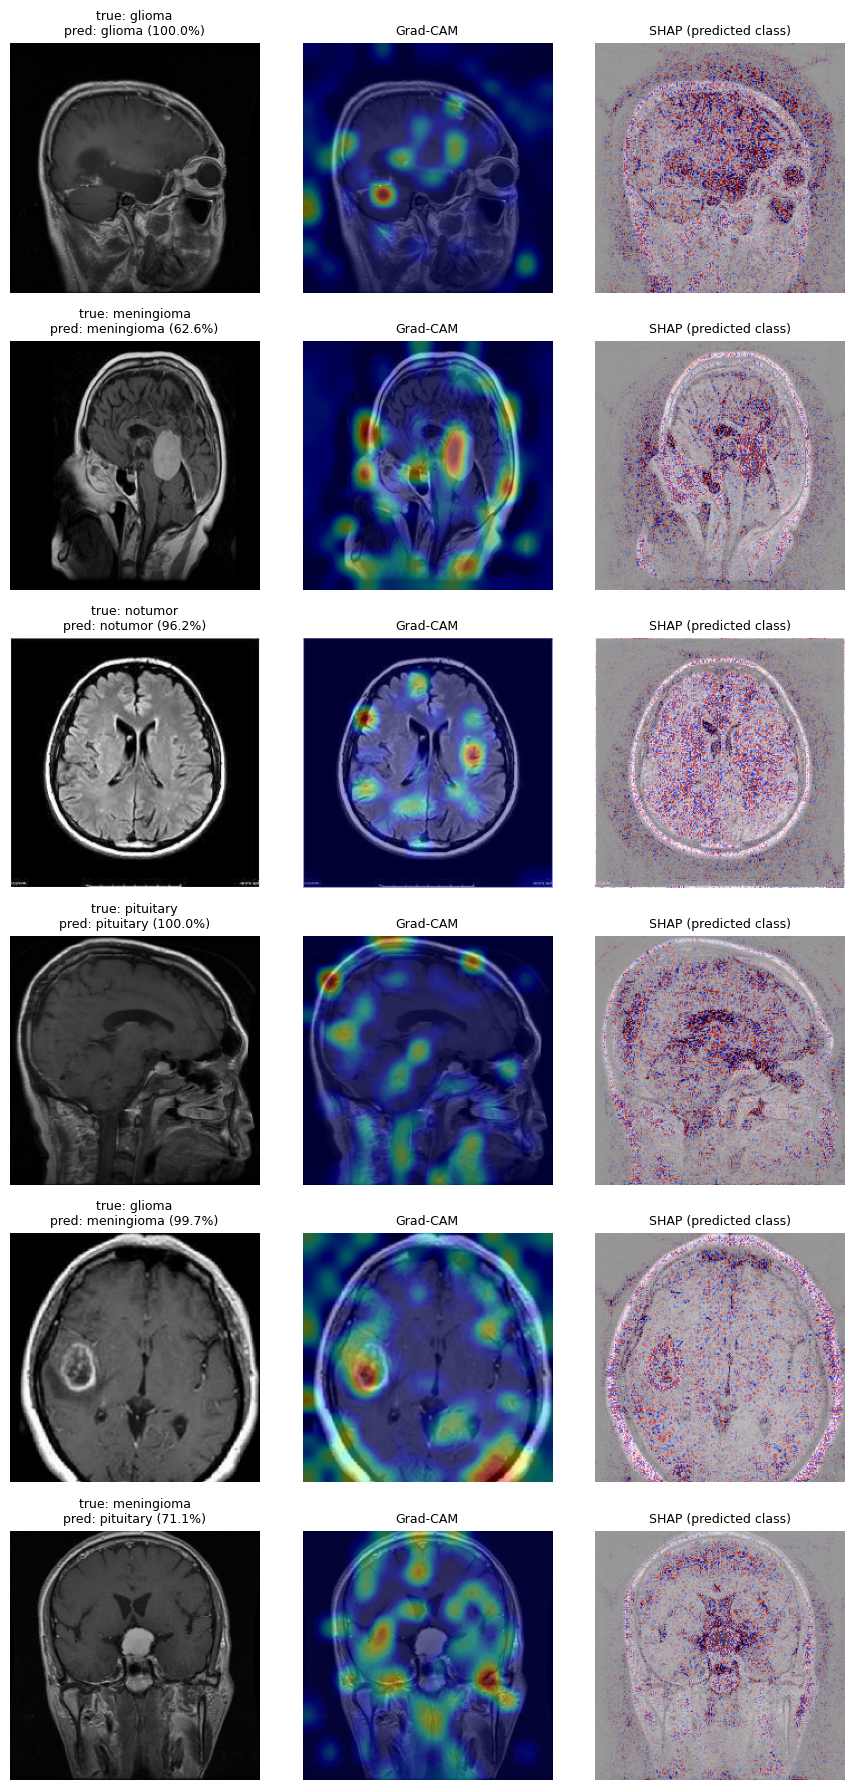

Saved: gradcam_grid.png, shap_grid.png, gradcam_shap_combined.png


In [2]:
import cv2, shap
import numpy as np

SEED = 7
LAYER_HI = "block6a_expand_activation"   # 14x14 map (sharper)
LAYER_LO = "top_activation"              # 7x7 map (what you had before)
rng = np.random.default_rng(SEED)

# ---------- Grad-CAM at any backbone layer ----------
tail_dense = [l for l in model.layers if isinstance(l, layers.Dense) and l.units == 256
              and l.activation.__name__ == "relu" and l.name != "cnn_projection"][0]
tail_dropout = [l for l in model.layers if isinstance(l, layers.Dropout)
                and abs(l.rate - 0.3) < 1e-6][0]
vit_model = Model(model.input, model.get_layer("vit_gap").output)

def make_cam(layer_name):
    extractor = Model(cnn_backbone.input,
                      [cnn_backbone.get_layer(layer_name).output,
                       cnn_backbone.get_layer("top_activation").output])
    def cam(image, class_index=None):
        img = tf.expand_dims(tf.cast(image, tf.float32), 0)
        pre = model.get_layer("cnn_preprocess")(img)
        f_vit = vit_model(img, training=False)
        logits_vit = model.get_layer("vit_logits")(f_vit)
        with tf.GradientTape() as tape:
            tape.watch(pre)
            target_maps, top_maps = extractor(pre, training=False)
            pooled = tf.reduce_mean(top_maps, axis=(1, 2))
            f_cnn = model.get_layer("cnn_projection")(pooled)
            logits_cnn = model.get_layer("cnn_logits")(f_cnn)
            fused, _, _ = model.get_layer("confidence_fusion")(
                [f_cnn, f_vit, logits_cnn, logits_vit])
            h = tail_dropout(tail_dense(fused), training=False)
            probs = tf.nn.softmax(model.get_layer("final_logits")(h), axis=-1)
            if class_index is None:
                class_index = int(tf.argmax(probs[0]))
            score = probs[:, class_index]
        grads = tape.gradient(score, target_maps)
        w = tf.reduce_mean(grads, axis=(0, 1, 2))
        hm = tf.squeeze(target_maps[0] @ w[..., tf.newaxis])
        hm = tf.maximum(hm, 0) / (tf.reduce_max(hm) + 1e-8)
        hm = cv2.resize(hm.numpy(), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
        return np.clip(hm, 0, 1)
    return cam

try:
    cam_hi = make_cam(LAYER_HI)
except Exception as e:
    print("14x14 layer not available, using 7x7:", e)
    cam_hi = make_cam(LAYER_LO)
cam_lo = make_cam(LAYER_LO)

# ---------- pick samples (random, not hand-picked) ----------
y_true, y_pred = [], []
for xb, yb in test_ds_labeled:
    y_true.append(np.argmax(yb["final_output"].numpy(), 1))
    y_pred.append(np.argmax(model.predict(xb, verbose=0)[0], 1))
y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

idx_list = [int(rng.choice(np.where(y_true == c)[0])) for c in range(NUM_CLASSES)]
wrong = np.where(y_true != y_pred)[0]
if len(wrong):
    idx_list += [int(i) for i in rng.choice(wrong, size=min(2, len(wrong)), replace=False)]
print("Chosen test indices:", idx_list)

imgs, offset, wanted = {}, 0, set(idx_list)
for xb, _ in test_ds_labeled:
    for j in range(len(xb)):
        if offset + j in wanted:
            imgs[offset + j] = xb[j].numpy()
    offset += len(xb)
samples = np.stack([imgs[i] for i in idx_list])
t_lab = [y_true[i] for i in idx_list]
probs = model.predict(samples, verbose=0)[0]
p_lab = probs.argmax(1)
n = len(samples)

def overlay(ax, img, hm, cmap="jet", alpha=0.4, vmin=None, vmax=None):
    ax.imshow(np.clip(img, 0, 255).astype("uint8"))
    ax.imshow(hm, cmap=cmap, alpha=alpha, vmin=vmin, vmax=vmax)
    ax.axis("off")

# ---------- Figure 1: Grad-CAM grid ----------
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
for i in range(n):
    axes[i, 0].imshow(np.clip(samples[i], 0, 255).astype("uint8")); axes[i, 0].axis("off")
    axes[i, 0].set_title(f"true: {CLASS_NAMES[t_lab[i]]}\npred: {CLASS_NAMES[p_lab[i]]} ({probs[i][p_lab[i]]*100:.1f}%)", fontsize=9)
    overlay(axes[i, 1], samples[i], cam_hi(samples[i]));  axes[i, 1].set_title("Grad-CAM (fine)", fontsize=9)
    overlay(axes[i, 2], samples[i], cam_lo(samples[i]));  axes[i, 2].set_title("Grad-CAM (7x7)", fontsize=9)
plt.tight_layout(); plt.savefig("gradcam_grid.png", dpi=200); plt.show()

# ---------- SHAP (explain logits so gradients don't vanish) ----------
bg_x, _ = next(iter(train_ds))
background = bg_x[:20].numpy()
shap_model = Model(model.input, model.get_layer("final_logits").output)
sv = shap.GradientExplainer(shap_model, background).shap_values(samples)
if isinstance(sv, np.ndarray) and sv.ndim == samples.ndim + 1:
    sv = [sv[..., k] for k in range(sv.shape[-1])]          # one array per class

labels = np.array([CLASS_NAMES] * n)
shap.image_plot(sv, samples / 255.0, labels=labels, show=False)
plt.savefig("shap_grid.png", dpi=200, bbox_inches="tight"); plt.show()

# ---------- Figure 3: combined (paper figure) ----------
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
for i in range(n):
    axes[i, 0].imshow(np.clip(samples[i], 0, 255).astype("uint8")); axes[i, 0].axis("off")
    axes[i, 0].set_title(f"true: {CLASS_NAMES[t_lab[i]]}\npred: {CLASS_NAMES[p_lab[i]]} ({probs[i][p_lab[i]]*100:.1f}%)", fontsize=9)
    overlay(axes[i, 1], samples[i], cam_hi(samples[i], class_index=int(p_lab[i])))
    axes[i, 1].set_title("Grad-CAM", fontsize=9)
    m = sv[p_lab[i]][i].sum(-1)
    lim = np.percentile(np.abs(m), 99.5) + 1e-12
    overlay(axes[i, 2], samples[i], m, cmap="seismic", alpha=0.6, vmin=-lim, vmax=lim)
    axes[i, 2].set_title("SHAP (predicted class)", fontsize=9)
plt.tight_layout(); plt.savefig("gradcam_shap_combined.png", dpi=200); plt.show()

print("Saved: gradcam_grid.png, shap_grid.png, gradcam_shap_combined.png")

In [3]:
# ============================================================================
# ABLATION STUDY (Section 6.5)
# Compares: CNN-only, ViT-only, Static-Fusion (fixed 50/50), and the full
# Adaptive Confidence-Guided Fusion model, all trained the same way on the
# same data, so the comparison is fair. Requires train_ds, val_ds,
# test_ds_labeled, CLASS_NAMES, NUM_CLASSES, IMG_SIZE, PROJ_DIM etc. from
# your existing notebook to already be defined.
# ============================================================================
import time
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def build_cnn_only():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")
    f_cnn, cnn_backbone = build_cnn_branch(inputs)
    logits = layers.Dense(NUM_CLASSES)(f_cnn)
    out = layers.Activation("softmax", name="final_output")(logits)
    m = Model(inputs, out, name="CNN_only")
    m.compile(optimizer=tf.keras.optimizers.Adam(LR),
               loss="categorical_crossentropy", metrics=["accuracy"])
    return m, cnn_backbone


def build_vit_only():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")
    f_vit = build_vit_branch(inputs)
    logits = layers.Dense(NUM_CLASSES)(f_vit)
    out = layers.Activation("softmax", name="final_output")(logits)
    m = Model(inputs, out, name="ViT_only")
    m.compile(optimizer=tf.keras.optimizers.Adam(LR),
               loss="categorical_crossentropy", metrics=["accuracy"])
    return m


def build_static_fusion():
    """Same two branches as ACGHV, but fused with a FIXED 0.5/0.5 weight
    instead of the confidence-guided alpha/beta -> isolates the value of
    the adaptive fusion mechanism itself (Eq. 3-6 vs simple averaging)."""
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")
    f_cnn, cnn_backbone = build_cnn_branch(inputs)
    f_vit = build_vit_branch(inputs)
    fused = layers.Average()([f_cnn, f_vit])          # fixed 0.5/0.5, no confidence
    x = layers.Dense(256, activation="relu")(fused)
    x = layers.Dropout(0.3)(x)
    logits = layers.Dense(NUM_CLASSES)(x)
    out = layers.Activation("softmax", name="final_output")(logits)
    m = Model(inputs, out, name="Static_Fusion")
    m.compile(optimizer=tf.keras.optimizers.Adam(LR),
               loss="categorical_crossentropy", metrics=["accuracy"])
    return m, cnn_backbone


def to_single_target(x, y):
    # ablation variants have one output head, unlike the full ACGHV model
    return x, y["final_output"]


train_ds_single = train_ds.map(to_single_target)
val_ds_single = val_ds.map(to_single_target)
test_ds_single = test_ds_labeled.map(to_single_target)


def count_params(m):
    return int(np.sum([tf.size(w).numpy() for w in m.trainable_weights]))


def eval_model(m, ds):
    y_true, y_prob = [], []
    for xb, yb in ds:
        pred = m.predict(xb, verbose=0)
        if isinstance(pred, list):       # multi-output model (full ACGHV) -> take final_output
            pred = pred[0]
        y_prob.append(pred)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true); y_prob = np.concatenate(y_prob)
    y_pred = y_prob.argmax(1); y_t = y_true.argmax(1)
    acc = (y_pred == y_t).mean()
    _, _, f1, _ = precision_recall_fscore_support(y_t, y_pred, average="macro", zero_division=0)
    y_bin = label_binarize(y_t, classes=list(range(NUM_CLASSES)))
    macro_auc = np.mean([auc(*roc_curve(y_bin[:, i], y_prob[:, i])[:2]) for i in range(NUM_CLASSES)])
    return acc, f1, macro_auc


ABLATION_EPOCHS = 25   # fewer than main run is fine here; keep consistent across variants
results = []

configs = {
    "CNN-only":       lambda: build_cnn_only(),
    "ViT-only":       lambda: (build_vit_only(), None),
    "Static-Fusion (avg)": lambda: build_static_fusion(),
}

for name, builder in configs.items():
    print(f"\n=== Training {name} ===")
    out = builder()
    m, _ = out if isinstance(out, tuple) else (out, None)
    cb = [tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6,
                                            restore_best_weights=True, mode="max")]
    t0 = time.time()
    m.fit(train_ds_single, validation_data=val_ds_single, epochs=ABLATION_EPOCHS, callbacks=cb, verbose=1)
    train_time = time.time() - t0
    acc, f1, macro_auc = eval_model(m, test_ds_single)
    results.append({"Variant": name, "Test Accuracy": acc, "Macro F1": f1,
                     "Macro AUC-ROC": macro_auc, "Trainable Params": count_params(m),
                     "Train Time (s)": round(train_time, 1)})
    print(f"{name}: acc={acc*100:.2f}%  f1={f1:.4f}  auc={macro_auc:.4f}")

# --- full ACGHV (adaptive confidence-guided fusion) ---
# Reuses your already-trained `model` if it exists and was trained with the
# same EPOCHS budget; otherwise trains fresh for a fair comparison.
print("\n=== Evaluating Adaptive Confidence-Guided Fusion (full ACGHV) ===")
acc, f1, macro_auc = eval_model(model, test_ds_labeled.map(lambda x, y: (x, y["final_output"])))
results.append({"Variant": "Adaptive Confidence-Guided Fusion (ours)",
                 "Test Accuracy": acc, "Macro F1": f1, "Macro AUC-ROC": macro_auc,
                 "Trainable Params": count_params(model), "Train Time (s)": "see Section 6.6"})

df = pd.DataFrame(results)
df["Test Accuracy"] = (df["Test Accuracy"] * 100).round(2).astype(str) + "%"
df["Macro F1"] = df["Macro F1"].round(4)
df["Macro AUC-ROC"] = df["Macro AUC-ROC"].round(4)
print("\n" + "=" * 80)
print(df.to_string(index=False))
df.to_csv("ablation_results.csv", index=False)
print("\nSaved ablation_results.csv -- use these exact numbers in Section 6.5, Table.")


=== Training CNN-only ===
Epoch 1/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 110s 559ms/step - accuracy: 0.8032 - loss: 0.5309 - val_accuracy: 0.7952 - val_loss: 0.5717
Epoch 2/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 62s 414ms/step - accuracy: 0.8824 - loss: 0.3058 - val_accuracy: 0.9060 - val_loss: 0.2609
Epoch 3/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 61s 404ms/step - accuracy: 0.9151 - loss: 0.2282 - val_accuracy: 0.8940 - val_loss: 0.2765
Epoch 4/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 62s 411ms/step - accuracy: 0.9328 - loss: 0.1887 - val_accuracy: 0.9083 - val_loss: 0.2281
Epoch 5/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 62s 412ms/step - accuracy: 0.9361 - loss: 0.1716 - val_accuracy: 0.9214 - val_loss: 0.2251
Epoch 6/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 406ms/step - accuracy: 0.9489 - loss: 0.1387 - val_accuracy: 0.9179 - val_loss: 0.1931
Epoch 7/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 412ms/step - accuracy: 0.9569 - loss: 0.1209 - val_accuracy: 0.9393 - val_loss: 0.1473
Epoch 8/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 407ms/step 